# What the lift is worth (illustrative)

The bought-vs-built lift is measured. This notebook translates that measured lift into a value per applicant, so the buy-vs-build call has a number attached. The dataset's currency is unknown, so the headline result is expressed as a **share of loan value** (currency-free); the raw per-applicant figures below are in the dataset's own units and are illustrative only.

**Read this as a frontier, not a fact.** The AUC lift and the loan amounts are real. The loan economics (loss given default, profit margin, term) are not in this dataset, so they are swept over a plausible range. The output is *where* buying the score pays off, not a single guaranteed figure.

Method: take the real out-of-fold predictions from the internal-only model and the combined model, approve the lowest-risk applicants under each, and price the difference. The better-ranking model approves a cheaper book; that difference is what the purchased scores are worth.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import INTERIM, RAW

runs = INTERIM / "runs"
p_int = pd.read_pickle(runs / "engineered_internal_only.pkl").rename("p_int")
p_comb = pd.read_pickle(runs / "engineered_combined.pkl").rename("p_comb")
app = pd.read_csv(RAW / "application_train.csv", usecols=["SK_ID_CURR", "TARGET", "AMT_CREDIT"]).set_index("SK_ID_CURR")

df = app.join(p_int).join(p_comb).dropna()
y, amt, n = df["TARGET"], df["AMT_CREDIT"], len(df)
GRAY, ACCENT, TXT = "#C9C9C9", "#3F7CAC", "#404040"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120})
print(f"{n:,} applicants | default rate {y.mean():.1%} | median loan {amt.median():,.0f} (dataset currency units)")

307,511 applicants | default rate 8.1% | median loan 513,531 (dataset currency units)


## The profit model

Approve the K% of applicants a model ranks safest. An approved good loan earns `margin x amount`; an approved default loses `LGD x amount`. The value of the lift is the extra profit from ranking with the combined model instead of the internal-only model, at the same approval rate.

In [2]:
def profit(p, K, lgd, margin):
    approved = p.nsmallest(int(K * n)).index
    a = amt.loc[approved]; bad = y.loc[approved] == 1
    return margin * a[~bad].sum() - lgd * a[bad].sum()

def lift_value(K, lgd, margin):
    return profit(df["p_comb"], K, lgd, margin) - profit(df["p_int"], K, lgd, margin)

# base-case assumptions (swept below)
K, LGD, MARGIN = 0.90, 0.60, 0.15
gross = lift_value(K, LGD, MARGIN)
print(f"Base case: approve {K:.0%}, loss given default {LGD:.0%}, margin {MARGIN:.0%}")
print(f"  value of the lift, total       : {gross:,.0f}")
print(f"  value of the lift, per applicant: {gross / n:,.2f}")
print(f"  -> buy the score if it costs LESS than {gross / n:,.2f} per applicant")
print(f"  on a 100,000-loan book, worth about {gross / n * 100_000:,.0f}")

Base case: approve 90%, loss given default 60%, margin 15%
  value of the lift, total       : 325,829,905
  value of the lift, per applicant: 1,059.57
  -> buy the score if it costs LESS than 1,059.57 per applicant
  on a 100,000-loan book, worth about 105,957,154


## The lift is worth most when you are selective

At a 100% approval rate the ranking does not matter, so the lift is worth nothing. The tighter the approval policy, the more a better ranking is worth.

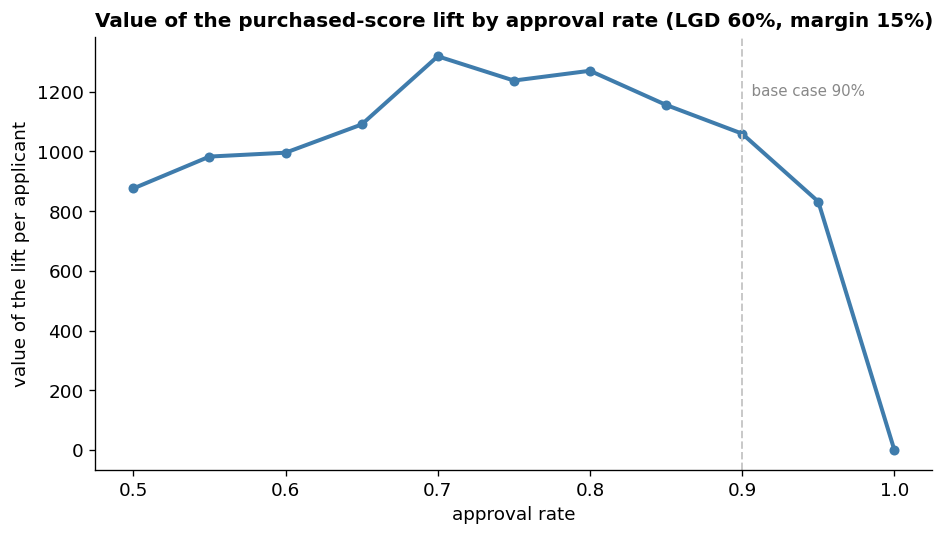

In [3]:
Ks = np.round(np.arange(0.50, 1.001, 0.05), 2)
vals = [lift_value(k, LGD, MARGIN) / n for k in Ks]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(Ks, vals, color=ACCENT, lw=2.4, marker="o", ms=5)
ax.axvline(K, color=GRAY, ls="--", lw=1.2); ax.text(K, max(vals) * 0.9, f"  base case {K:.0%}", color="#888", fontsize=9)
ax.set_xlabel("approval rate"); ax.set_ylabel("value of the lift per applicant")
ax.set_title(f"Value of the purchased-score lift by approval rate (LGD {LGD:.0%}, margin {MARGIN:.0%})",
             loc="left", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

## The frontier: value per applicant across loan economics

How the value per applicant moves as loss given default and margin change (at the base-case approval rate). Compare a cell to the price of the score: buy where the value is above what the score costs.

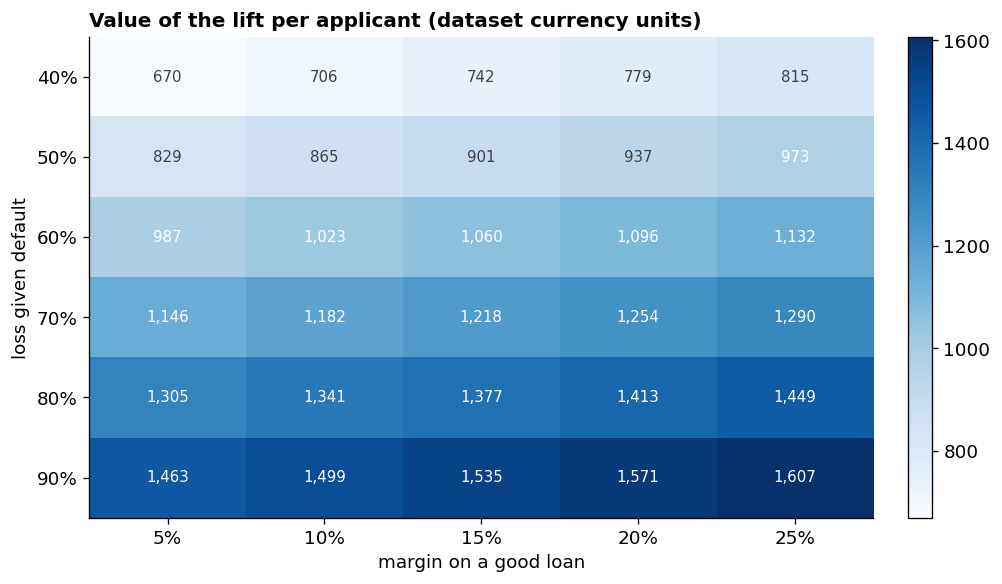

In [4]:
LGDs = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
MARGINs = [0.05, 0.10, 0.15, 0.20, 0.25]
M = np.array([[lift_value(K, lg, mg) / n for mg in MARGINs] for lg in LGDs])

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(M, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(MARGINs))); ax.set_xticklabels([f"{m:.0%}" for m in MARGINs])
ax.set_yticks(range(len(LGDs))); ax.set_yticklabels([f"{l:.0%}" for l in LGDs])
ax.set_xlabel("margin on a good loan"); ax.set_ylabel("loss given default")
for i in range(len(LGDs)):
    for j in range(len(MARGINs)):
        ax.text(j, i, f"{M[i, j]:,.0f}", ha="center", va="center", fontsize=9,
                color=("white" if M[i, j] > M.max() * 0.6 else TXT))
ax.set_title("Value of the lift per applicant (dataset currency units)", loc="left", fontweight="bold", fontsize=12)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## As a share of loan value (currency-agnostic)

The dollar figures depend on the dataset's currency, which we do not know. Expressing the value as a percent of loan value sidesteps that: it is the same whatever the currency, and it gives a clean break-even rule. Value per applicant divided by the average loan equals the lift value as a share of total loan volume.

In [5]:
vol = amt.sum()
base_pct = lift_value(K, LGD, MARGIN) / vol * 100
print(f"Base case (approve {K:.0%}, LGD {LGD:.0%}, margin {MARGIN:.0%}):")
print(f"  the lift is worth {base_pct:.2f}% of loan value per applicant")
print(f"  on a median {amt.median():,.0f} loan, that is {base_pct / 100 * amt.median():,.0f}")
print(f"  BREAK-EVEN: buy the score when its price is below {base_pct:.2f}% of the loan\n")

print("frontier, value as % of loan value   (rows = LGD, cols = margin)")
print("        " + "".join(f"m{int(mg * 100):>2}%   " for mg in MARGINs))
for lg in LGDs:
    print(f"LGD {int(lg * 100):>2}%  " + "".join(f"{lift_value(K, lg, mg) / vol * 100:>5.2f}   " for mg in MARGINs))

Base case (approve 90%, LGD 60%, margin 15%):
  the lift is worth 0.18% of loan value per applicant
  on a median 513,531 loan, that is 908
  BREAK-EVEN: buy the score when its price is below 0.18% of the loan

frontier, value as % of loan value   (rows = LGD, cols = margin)
        m 5%   m10%   m15%   m20%   m25%   
LGD 40%   0.11    0.12    0.12    0.13    0.14   
LGD 50%   0.14    0.14    0.15    0.16    0.16   
LGD 60%   0.16    0.17    0.18    0.18    0.19   
LGD 70%   0.19    0.20    0.20    0.21    0.22   
LGD 80%   0.22    0.22    0.23    0.24    0.24   
LGD 90%   0.24    0.25    0.26    0.26    0.27   


## The simple version: when to buy, when not to

The whole decision on one chart. The line is the break-even price (what the lift is worth). Find your loans' loss severity on the bottom and your score's price on the side: below the line the score costs less than it adds, so buy it; above the line it costs more than it is worth, so do not.

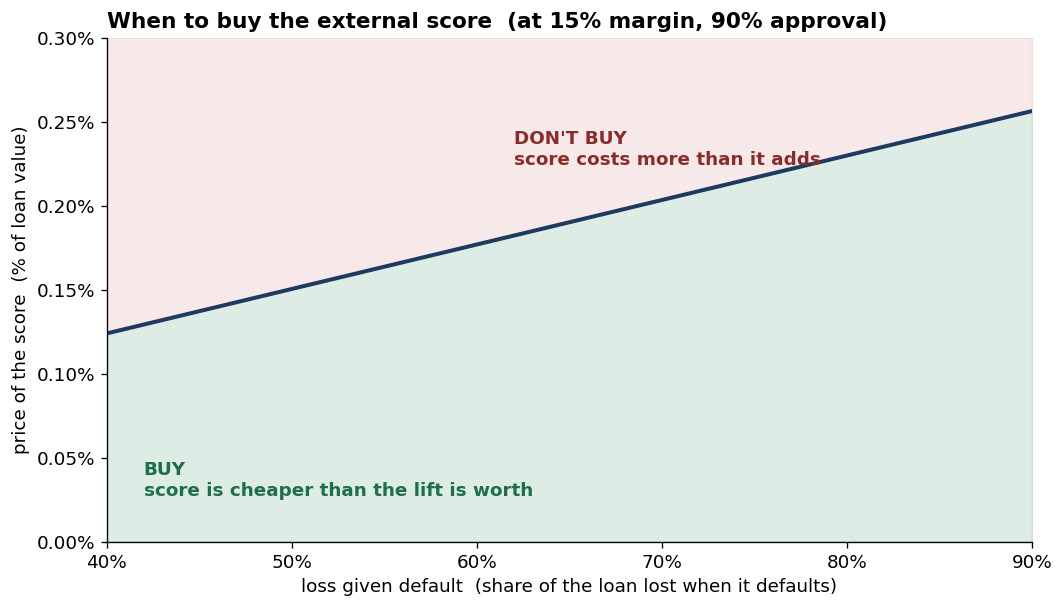

In [6]:
from matplotlib.ticker import FuncFormatter

lg = np.linspace(0.40, 0.90, 40)
val = np.array([lift_value(K, l, MARGIN) / vol * 100 for l in lg])   # break-even price, % of loan
ymax = 0.30

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.fill_between(lg, 0, val, color="#2E8B57", alpha=0.16)
ax.fill_between(lg, val, ymax, color="#C0504D", alpha=0.12)
ax.plot(lg, val, color="#1f3a5f", lw=2.4)
ax.text(0.42, 0.025, "BUY\nscore is cheaper than the lift is worth", color="#1f6f4a",
        fontsize=11, fontweight="bold", va="bottom")
ax.text(0.62, 0.245, "DON'T BUY\nscore costs more than it adds", color="#8a2d2a",
        fontsize=11, fontweight="bold", va="top")
ax.set_xlim(0.40, 0.90); ax.set_ylim(0, ymax)
ax.set_xlabel("loss given default  (share of the loan lost when it defaults)")
ax.set_ylabel("price of the score  (% of loan value)")
ax.set_title(f"When to buy the external score  (at {MARGIN:.0%} margin, {K:.0%} approval)",
             loc="left", fontweight="bold", fontsize=13)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(round(v * 100))}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}%"))
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## The rule, with a worked example

The break-even line is a percent of the loan. To compare it to a real price, turn it into money by multiplying by the loan amount, then buy if the score costs less than that.

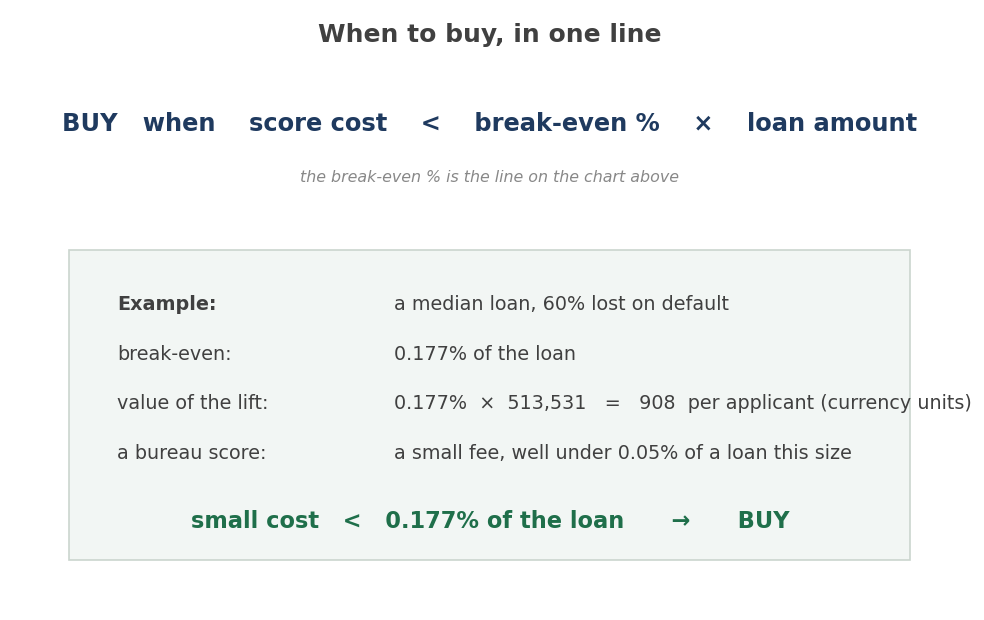

In [7]:
med = amt.median()
be = lift_value(K, LGD, MARGIN) / vol * 100
val = be / 100 * med
GREEN = "#1f6f4a"

fig, ax = plt.subplots(figsize=(9, 5.3)); ax.axis("off")
ax.text(0.5, 0.95, "When to buy, in one line", ha="center", fontsize=15, fontweight="bold", color=TXT)
ax.text(0.5, 0.80, "BUY   when    score cost    <    break-even %    ×    loan amount",
        ha="center", fontsize=14.5, color="#1f3a5f", fontweight="bold")
ax.text(0.5, 0.715, "the break-even % is the line on the chart above", ha="center", fontsize=9.5, color="#888", style="italic")
ax.add_patch(plt.Rectangle((0.06, 0.08), 0.88, 0.52, facecolor="#F2F6F4", edgecolor="#CBD5CE", lw=1))
lines = [
    ("Example", "a median loan, 60% lost on default", "bold"),
    ("break-even", f"{be:.3f}% of the loan", "normal"),
    ("value of the lift", f"{be:.3f}%  ×  {med:,.0f}   =   {val:,.0f}  per applicant (currency units)", "normal"),
    ("a bureau score", "a small fee, well under 0.05% of a loan this size", "normal"),
]
y0 = 0.50
for i, (lab, txt, w) in enumerate(lines):
    ax.text(0.11, y0 - i * 0.083, lab + ":", fontsize=11.5, color=TXT, fontweight=w)
    ax.text(0.40, y0 - i * 0.083, txt, fontsize=11.5, color=TXT)
ax.text(0.5, 0.135, f"small cost   <   {be:.3f}% of the loan      →      BUY", ha="center", fontsize=13.5, color=GREEN, fontweight="bold")
plt.tight_layout(); plt.show()

## Bottom line

The measured lift converts to a per-applicant dollar value that grows with loss severity, loan margin, and how selective the approval policy is. The decision rule is simple: **buy the external score when its per-applicant price is below the value shown here.** That is "buy selectively" with a number attached, and every dollar figure is explicitly a function of the swept loan economics, not a measured result.